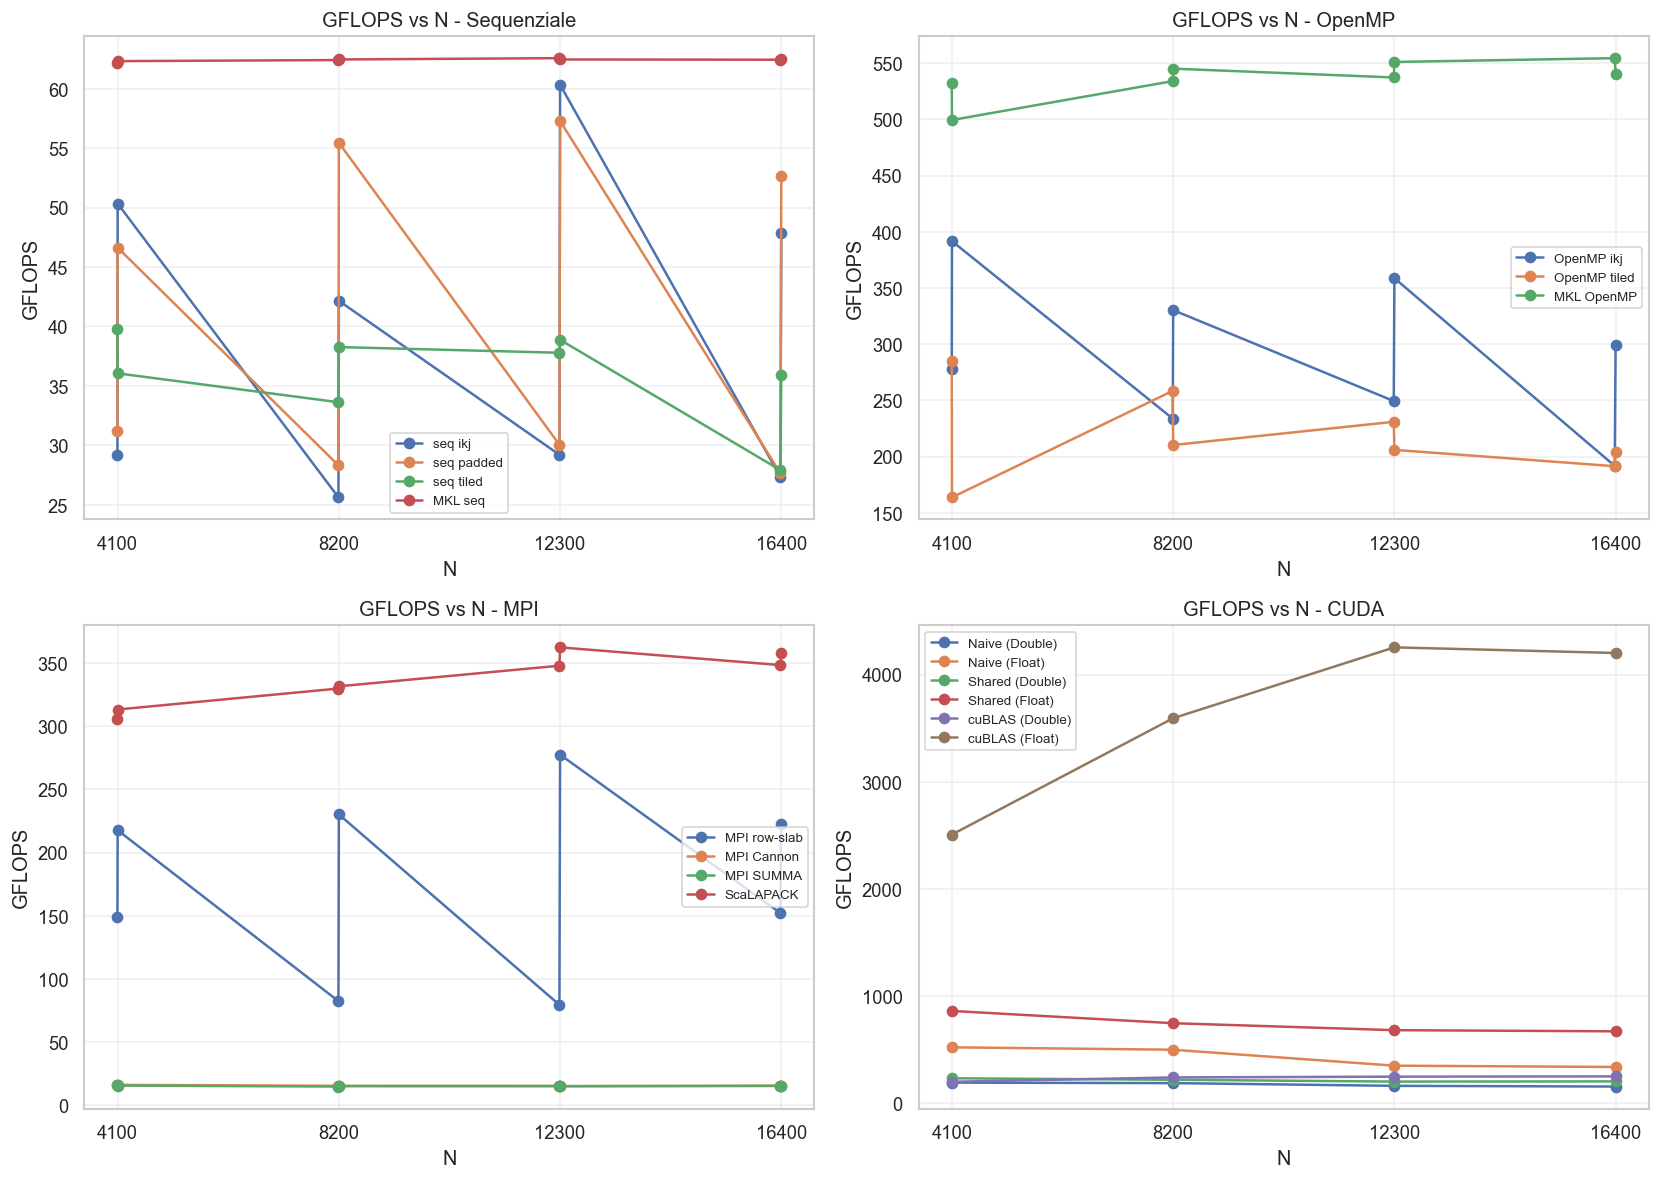

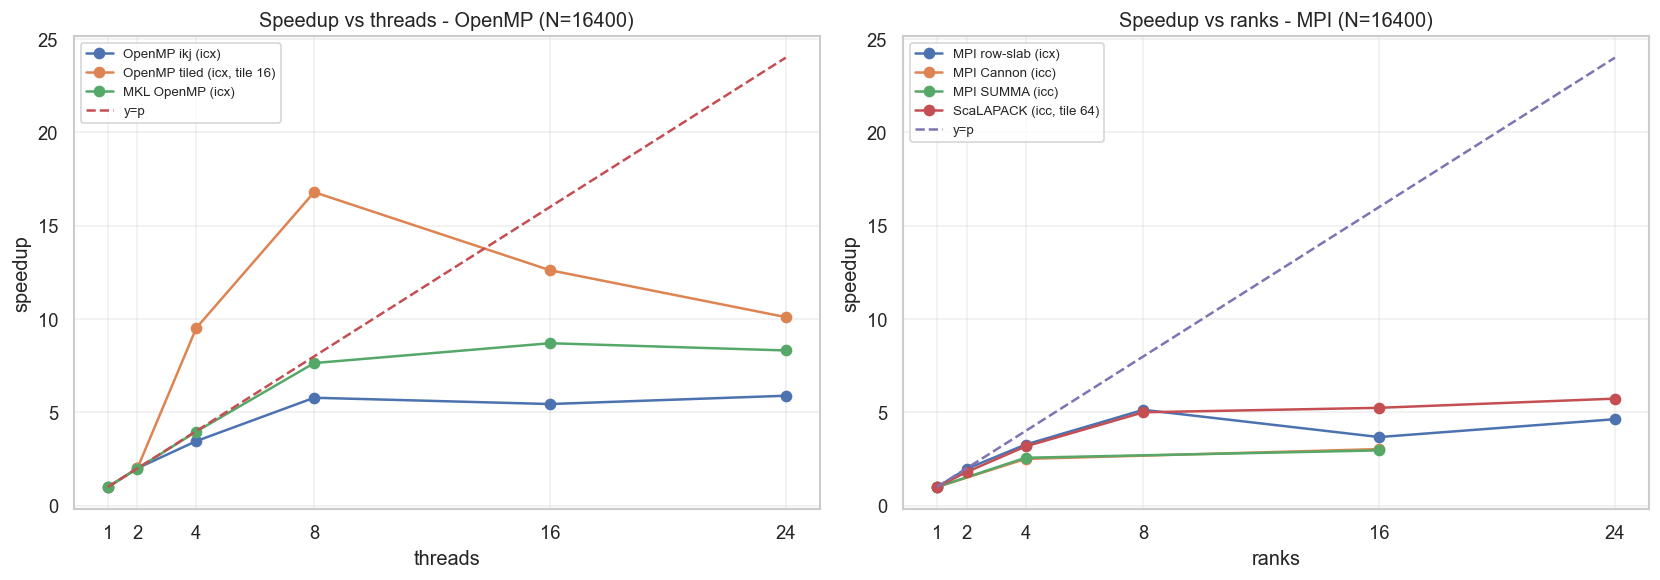

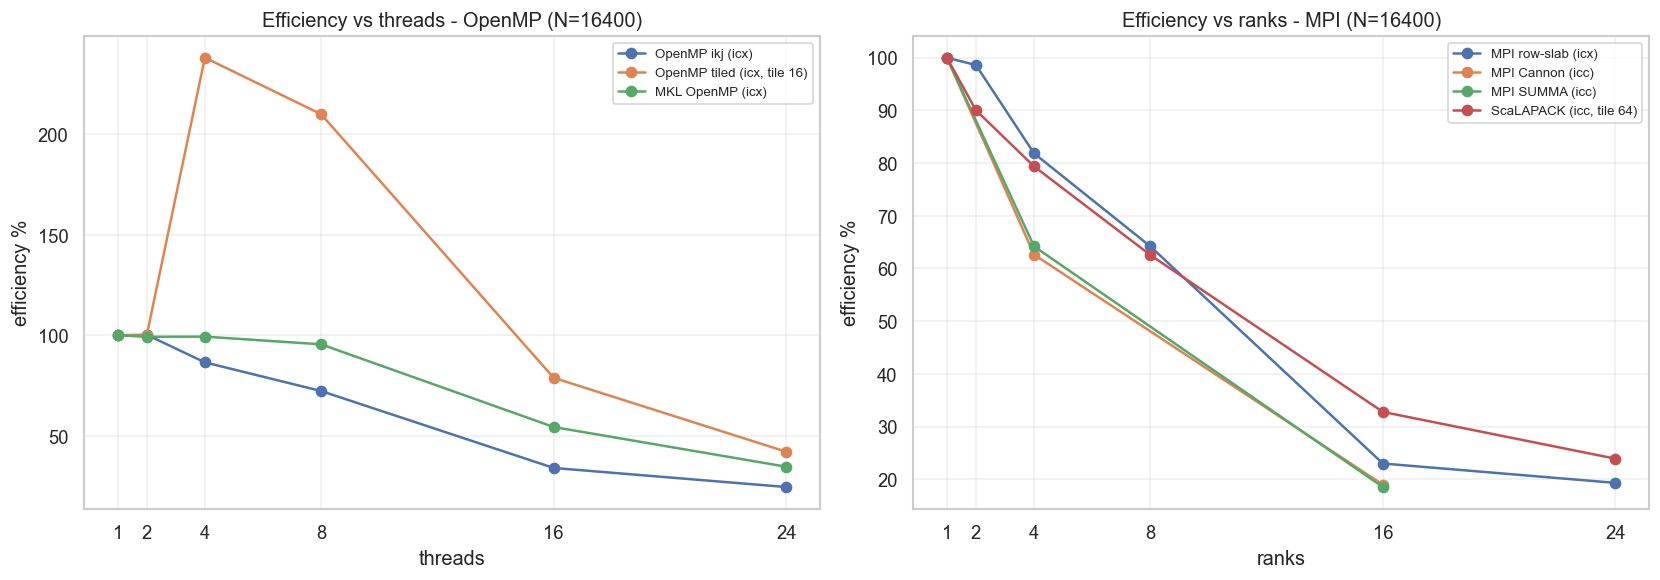

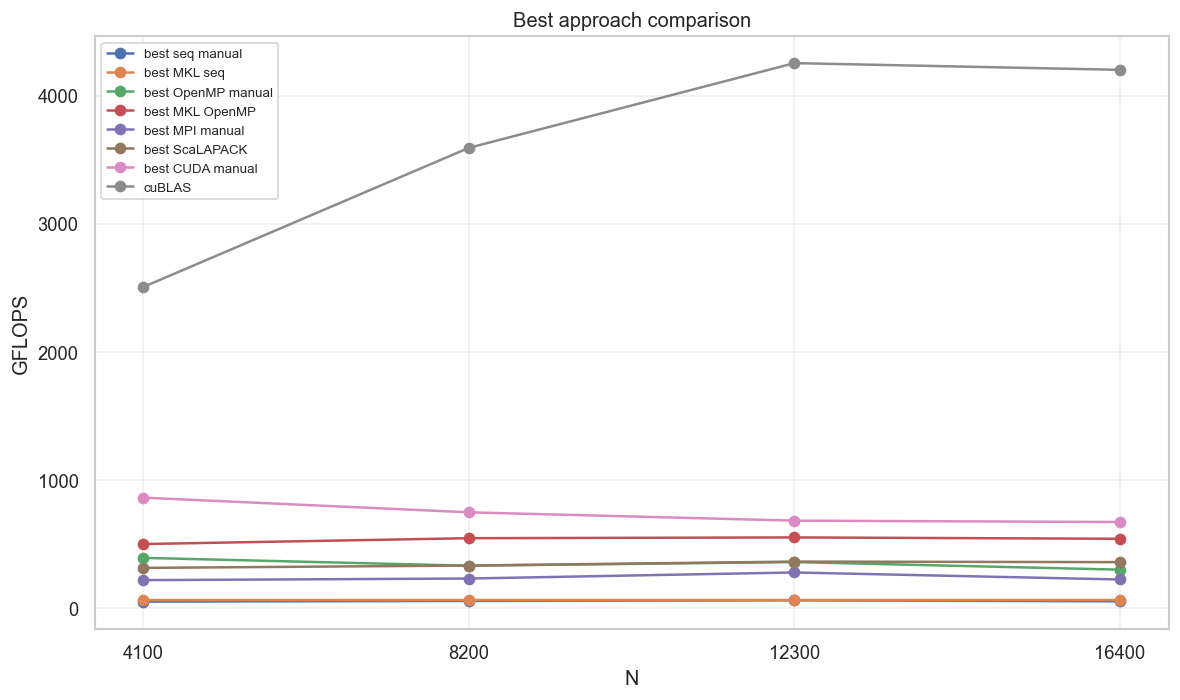

N usato per scaling: 16400

Configurazioni scelte per OpenMP:
 - OpenMP ikj (icx)
 - OpenMP tiled (icx, tile 16)
 - MKL OpenMP (icx)

Configurazioni scelte per MPI:
 - MPI row-slab (icx)
 - MPI Cannon (icc)
 - MPI SUMMA (icc)
 - ScaLAPACK (icc, tile 64)

N comuni per il confronto finale: [4100, 8200, 12300, 16400]


In [89]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Parametro principale
# =========================
N_SCALE = 16400   # N usato per speedup/efficiency

# =========================
# Lettura CSV
# =========================
def load_csv(filename):
    # prova più possibili posizioni relative e absolute in ordine
    candidates = [
        Path(filename),
        Path('metrics_tables') / filename,
        Path('plot_scripts') / 'metrics_tables' / filename,
        Path.cwd() / 'plot_scripts' / 'metrics_tables' / filename,
        Path.cwd() / 'metrics_tables' / filename,
        Path('/Users/irynasavchuk/Desktop/cartella senza nome/HPC-MATMUL/plot_scripts/metrics_tables') / filename,
    ]
    for p in candidates:
        if p.exists():
            return pd.read_csv(p)
    # fallback: cerca ricorsivamente nel progetto
    matches = list(Path('.').rglob(filename))
    if matches:
        return pd.read_csv(matches[0])
    raise FileNotFoundError(f"File non trovato: {filename}; cercati: {candidates}")

seq = load_csv("seq_all_metrics.csv")
omp = load_csv("omp_all_metrics.csv")
mpi = load_csv("mpi_all_metrics.csv")
cuda = load_csv("cuda_all_metrics.csv")

for df in (seq, omp, mpi, cuda):
    if "TileSize" in df.columns:
        df["TileSize"] = df["TileSize"].fillna("-").astype(str)
    if "Threads/Ranks" in df.columns:
        df["Threads/Ranks"] = pd.to_numeric(df["Threads/Ranks"], errors="coerce")

# =========================
# Etichette più leggibili
# =========================
nice = {
    "seq-ikj": "seq ikj",
    "seq-pad": "seq padded",
    "seq-tile": "seq tiled",
    "mkl-seq": "MKL seq",
    "omp-ikj": "OpenMP ikj",
    "omp-tile": "OpenMP tiled",
    "mkl-omp": "MKL OpenMP",
    "mpi-ikj": "MPI row-slab",
    "mpi-cannon": "MPI Cannon",
    "mpi-summa": "MPI SUMMA",
    "scalapack": "ScaLAPACK",
}

# =========================
# Helper
# =========================
def best_per_n(df, category_col, categories=None, n_values=None):
    """
    Per ogni categoria e per ogni N prende il record con GFLOPS massimo.
    Serve per i plot GFLOPS vs N e best comparison.
    """
    work = df.copy()
    if categories is None:
        categories = list(work[category_col].dropna().unique())

    rows = []
    for cat in categories:
        dcat = work[work[category_col] == cat]
        for n, g in dcat.groupby("N"):
            if (n_values is not None) and (n not in n_values):
                continue
            best = g.sort_values(["GFLOPS", "Time_s"], ascending=[False, True]).iloc[0]
            rows.append({
                "category": cat,
                "N": n,
                "GFLOPS": best["GFLOPS"]
            })
    return pd.DataFrame(rows)

def choose_best_scaling_config(df, test_name, n_value):
    """
    Sceglie UNA configurazione fissa per fare speedup/efficiency:
    stessa implementazione, stesso compiler, stesso tile, stesso align/restrict.
    Poi ricalcola speedup ed efficiency da Time_s usando come baseline p=1.
    """
    d = df[(df["Test"] == test_name) & (df["N"] == n_value)].copy()

    metric_cols = {"N", "Threads/Ranks", "Time_s", "GFLOPS", "Speedup", "Efficiency_%"}
    config_cols = [c for c in d.columns if c not in metric_cols | {"Test"}]

    candidates = []
    for key, g in d.groupby(config_cols, dropna=False):
        pr = sorted(g["Threads/Ranks"].dropna().astype(int).unique())

        # serve almeno il baseline 1 e almeno un altro punto
        if 1 not in pr or len(pr) < 2:
            continue

        # riduce eventuali duplicati sullo stesso p/rank
        reduced = g.groupby("Threads/Ranks", as_index=False).agg({
            "Time_s": "min",
            "GFLOPS": "max"
        }).sort_values("Threads/Ranks")

        base = reduced.loc[reduced["Threads/Ranks"] == 1, "Time_s"]
        if base.empty:
            continue

        base_t = float(base.iloc[0])
        reduced["Speedup_calc"] = base_t / reduced["Time_s"]
        reduced["Efficiency_calc"] = 100.0 * reduced["Speedup_calc"] / reduced["Threads/Ranks"]

        # prende la configurazione che raggiunge il GFLOPS massimo più alto
        score = reduced["GFLOPS"].max()

        if not isinstance(key, tuple):
            key = (key,)
        cfg = dict(zip(config_cols, key))
        cfg["Test"] = test_name

        candidates.append((score, cfg, reduced))

    if not candidates:
        return None, None

    candidates.sort(key=lambda x: x[0], reverse=True)
    return candidates[0][1], candidates[0][2]

def config_to_label(config):
    label = nice.get(config["Test"], config["Test"])
    extras = []
    if "Compiler" in config and pd.notna(config["Compiler"]):
        extras.append(str(config["Compiler"]))
    if "TileSize" in config and str(config["TileSize"]) not in ["-", "nan"]:
        extras.append(f"tile {config['TileSize']}")
    return f"{label} ({', '.join(extras)})" if extras else label

# =========================
# 1) GFLOPS vs N per famiglia
# =========================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# forzare i tick di N richiesti dall'utente
requested_N = [4100, 8200, 12300, 16400]

family_specs = [
    (
        seq,
        "Test",
        ["seq-ikj", "seq-pad", "seq-tile", "mkl-seq"],
        "GFLOPS vs N - Sequenziale"
    ),
    (
        omp,
        "Test",
        ["omp-ikj", "omp-tile", "mkl-omp"],
        "GFLOPS vs N - OpenMP"
    ),
    (
        mpi,
        "Test",
        ["mpi-ikj", "mpi-cannon", "mpi-summa", "scalapack"],
        "GFLOPS vs N - MPI"
    ),
    (
        cuda.assign(Cat=cuda["Algorithm"] + " (" + cuda["Precision"] + ")"),
        "Cat",
        sorted((cuda["Algorithm"] + " (" + cuda["Precision"] + ")").unique()),
        "GFLOPS vs N - CUDA"
    ),
]

for ax, (df, cat_col, cats, title) in zip(axes.flat, family_specs):
    curve = best_per_n(df, cat_col, cats)
    for cat in cats:
        s = curve[curve["category"] == cat].sort_values("N")
        if not s.empty:
            ax.plot(s["N"], s["GFLOPS"], marker="o", label=nice.get(cat, cat))
    ax.set_title(title)
    ax.set_xlabel("N")
    ax.set_ylabel("GFLOPS")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    # Forza i tick richiesti per N (anche se scala log)
    try:
        ax.set_xticks(requested_N)
        ax.set_xticklabels([str(x) for x in requested_N])
    except Exception:
        pass

fig.tight_layout()
plt.show()

# =========================
# 2) Speedup vs thread/rank
# =========================
omp_tests = ["omp-ikj", "omp-tile", "mkl-omp"]
mpi_tests = ["mpi-ikj", "mpi-cannon", "mpi-summa", "scalapack"]

omp_curves = []
for t in omp_tests:
    cfg, curve = choose_best_scaling_config(omp, t, N_SCALE)
    if curve is not None:
        omp_curves.append((cfg, curve))

mpi_curves = []
for t in mpi_tests:
    cfg, curve = choose_best_scaling_config(mpi, t, N_SCALE)
    if curve is not None:
        mpi_curves.append((cfg, curve))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# OpenMP
for cfg, curve in omp_curves:
    axes[0].plot(curve["Threads/Ranks"], curve["Speedup_calc"], marker="o", label=config_to_label(cfg))
if omp_curves:
    x_omp = sorted(set(np.concatenate([c["Threads/Ranks"].values for _, c in omp_curves])))
    axes[0].plot(x_omp, x_omp, linestyle="--", label="y=p")
axes[0].set_title(f"Speedup vs threads - OpenMP (N={N_SCALE})")
axes[0].set_xlabel("threads")
axes[0].set_ylabel("speedup")
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=8)
axes[0].set_xticks([1,2,4,8,16,24])

# MPI
for cfg, curve in mpi_curves:
    axes[1].plot(curve["Threads/Ranks"], curve["Speedup_calc"], marker="o", label=config_to_label(cfg))
if mpi_curves:
    x_mpi = sorted(set(np.concatenate([c["Threads/Ranks"].values for _, c in mpi_curves])))
    axes[1].plot(x_mpi, x_mpi, linestyle="--", label="y=p")
axes[1].set_title(f"Speedup vs ranks - MPI (N={N_SCALE})")
axes[1].set_xlabel("ranks")
axes[1].set_ylabel("speedup")
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=8)
axes[1].set_xticks([1,2,4,8,16,24])

fig.tight_layout()
plt.show()

# =========================
# 3) Efficiency vs thread/rank
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# OpenMP
for cfg, curve in omp_curves:
    axes[0].plot(curve["Threads/Ranks"], curve["Efficiency_calc"], marker="o", label=config_to_label(cfg))
axes[0].set_title(f"Efficiency vs threads - OpenMP (N={N_SCALE})")
axes[0].set_xlabel("threads")
axes[0].set_ylabel("efficiency %")
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=8)
axes[0].set_xticks([1,2,4,8,16,24])

# MPI
for cfg, curve in mpi_curves:
    axes[1].plot(curve["Threads/Ranks"], curve["Efficiency_calc"], marker="o", label=config_to_label(cfg))
axes[1].set_title(f"Efficiency vs ranks - MPI (N={N_SCALE})")
axes[1].set_xlabel("ranks")
axes[1].set_ylabel("efficiency %")
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=8)
axes[1].set_xticks([1,2,4,8,16,24])

fig.tight_layout()
plt.show()

# =========================
# 4) Best approach comparison
# =========================
common_n = sorted(set(seq["N"]) & set(omp["N"]) & set(mpi["N"]) & set(cuda["N"]))

comparison = {
    "best seq manual": seq[seq["Test"] != "mkl-seq"],
    "best MKL seq": seq[seq["Test"] == "mkl-seq"],
    "best OpenMP manual": omp[omp["Test"].isin(["omp-ikj", "omp-tile"])],
    "best MKL OpenMP": omp[omp["Test"] == "mkl-omp"],
    "best MPI manual": mpi[mpi["Test"].isin(["mpi-ikj", "mpi-cannon", "mpi-summa"])],
    "best ScaLAPACK": mpi[mpi["Test"] == "scalapack"],
    "best CUDA manual": cuda[cuda["Algorithm"] != "cuBLAS"],
    "cuBLAS": cuda[cuda["Algorithm"] == "cuBLAS"],
}

plt.figure(figsize=(10, 6))
for label, df in comparison.items():
    pts = []
    for n in common_n:
        g = df[df["N"] == n]
        if not g.empty:
            best = g.sort_values(["GFLOPS", "Time_s"], ascending=[False, True]).iloc[0]
            pts.append((n, best["GFLOPS"]))
    if pts:
        pts = pd.DataFrame(pts, columns=["N", "GFLOPS"])
        plt.plot(pts["N"], pts["GFLOPS"], marker="o", label=label)

# Forza ticks di N anche per questo confronto
try:
    ax = plt.gca()
    ax.set_xticks(requested_N)
    ax.set_xticklabels([str(x) for x in requested_N])
except Exception:
    pass

plt.title("Best approach comparison")
plt.xlabel("N")
plt.ylabel("GFLOPS")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# =========================
# Stampa utile finale
# =========================
print(f"N usato per scaling: {N_SCALE}")

print("\nConfigurazioni scelte per OpenMP:")
for cfg, _ in omp_curves:
    print(" -", config_to_label(cfg))

print("\nConfigurazioni scelte per MPI:")
for cfg, _ in mpi_curves:
    print(" -", config_to_label(cfg))

print("\nN comuni per il confronto finale:", common_n)


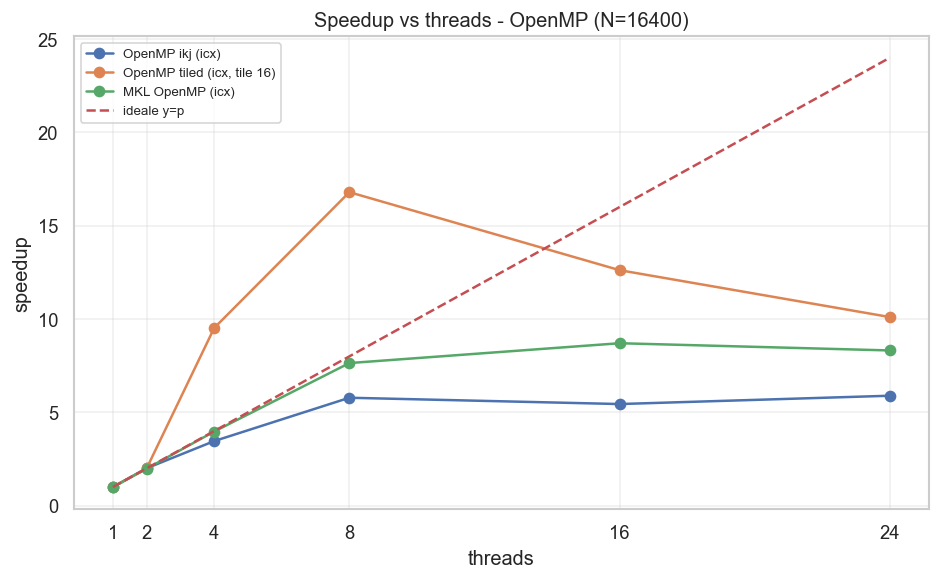

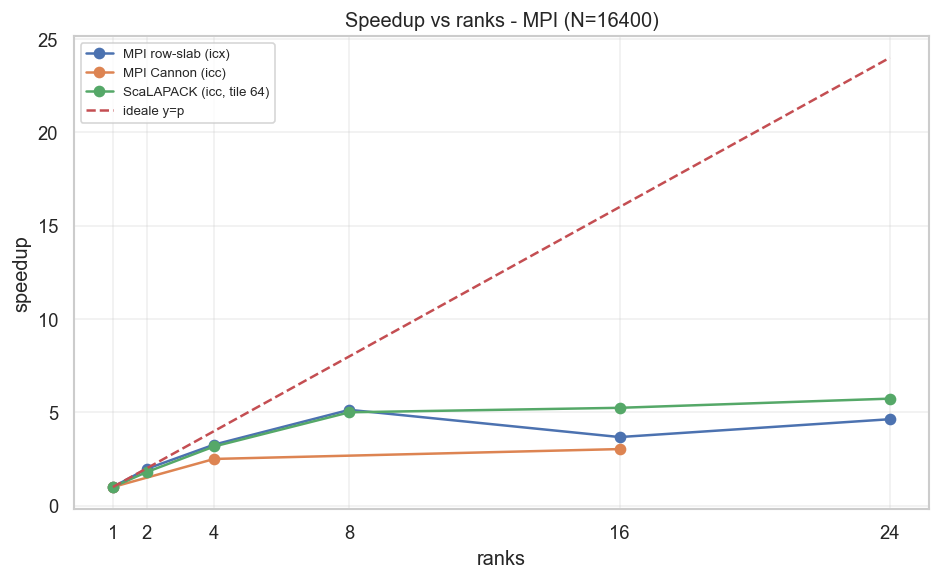

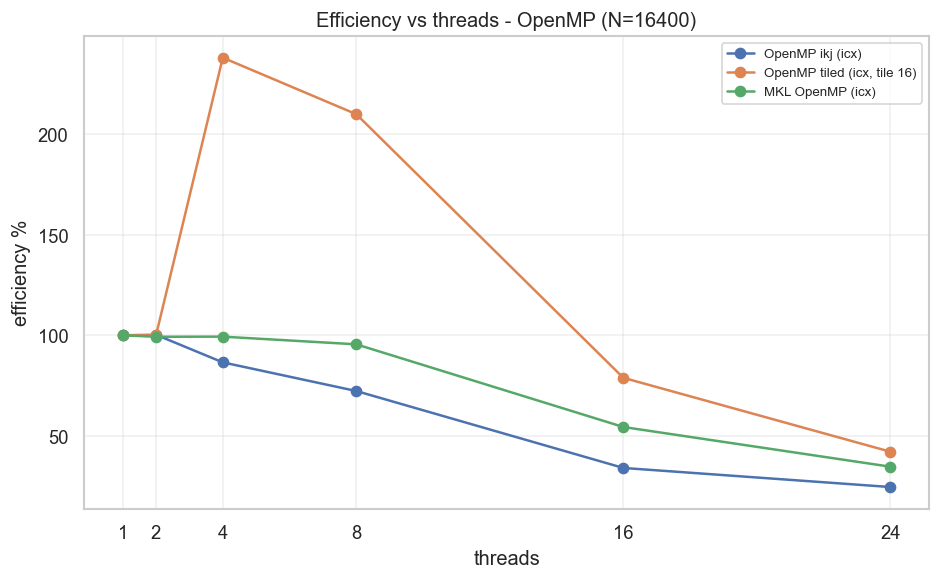

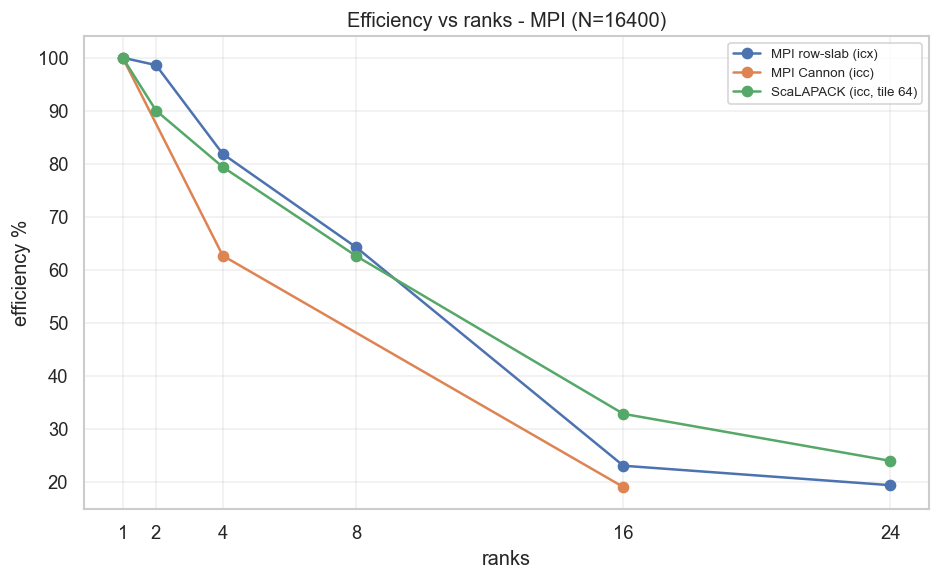

In [90]:
# =========================
# 2) Curves per scaling
# =========================
omp_tests = ["omp-ikj", "omp-tile", "mkl-omp"]
mpi_tests = ["mpi-ikj", "mpi-cannon", "scalapack"]

omp_curves = []
for t in omp_tests:
    cfg, curve = choose_best_scaling_config(omp, t, N_SCALE)
    if curve is not None:
        omp_curves.append((cfg, curve))

mpi_curves = []
for t in mpi_tests:
    cfg, curve = choose_best_scaling_config(mpi, t, N_SCALE)
    if curve is not None:
        mpi_curves.append((cfg, curve))

# =========================
# 3) Speedup - OpenMP
# =========================
plt.figure(figsize=(8, 5))

for cfg, curve in omp_curves:
    plt.plot(
        curve["Threads/Ranks"],
        curve["Speedup_calc"],
        marker="o",
        label=config_to_label(cfg)
    )

if omp_curves:
    x_omp = sorted(set(np.concatenate([c["Threads/Ranks"].values for _, c in omp_curves])))
    plt.plot(x_omp, x_omp, linestyle="--", label="ideale y=p")

plt.title(f"Speedup vs threads - OpenMP (N={N_SCALE})")
plt.xlabel("threads")
plt.ylabel("speedup")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.xticks([1, 2, 4, 8, 16, 24])
plt.tight_layout()
plt.show()

# =========================
# 4) Speedup - MPI
# =========================
plt.figure(figsize=(8, 5))

for cfg, curve in mpi_curves:
    plt.plot(
        curve["Threads/Ranks"],
        curve["Speedup_calc"],
        marker="o",
        label=config_to_label(cfg)
    )

if mpi_curves:
    x_mpi = sorted(set(np.concatenate([c["Threads/Ranks"].values for _, c in mpi_curves])))
    plt.plot(x_mpi, x_mpi, linestyle="--", label="ideale y=p")

plt.title(f"Speedup vs ranks - MPI (N={N_SCALE})")
plt.xlabel("ranks")
plt.ylabel("speedup")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.xticks([1, 2, 4, 8, 16, 24])
plt.tight_layout()
plt.show()

# =========================
# 5) Efficiency - OpenMP
# =========================
plt.figure(figsize=(8, 5))

for cfg, curve in omp_curves:
    plt.plot(
        curve["Threads/Ranks"],
        curve["Efficiency_calc"],
        marker="o",
        label=config_to_label(cfg)
    )

plt.title(f"Efficiency vs threads - OpenMP (N={N_SCALE})")
plt.xlabel("threads")
plt.ylabel("efficiency %")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.xticks([1, 2, 4, 8, 16, 24])
plt.tight_layout()
plt.show()

# =========================
# 6) Efficiency - MPI
# =========================
plt.figure(figsize=(8, 5))

for cfg, curve in mpi_curves:
    plt.plot(
        curve["Threads/Ranks"],
        curve["Efficiency_calc"],
        marker="o",
        label=config_to_label(cfg)
    )

plt.title(f"Efficiency vs ranks - MPI (N={N_SCALE})")
plt.xlabel("ranks")
plt.ylabel("efficiency %")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.xticks([1, 2, 4, 8, 16, 24])
plt.tight_layout()
plt.show()

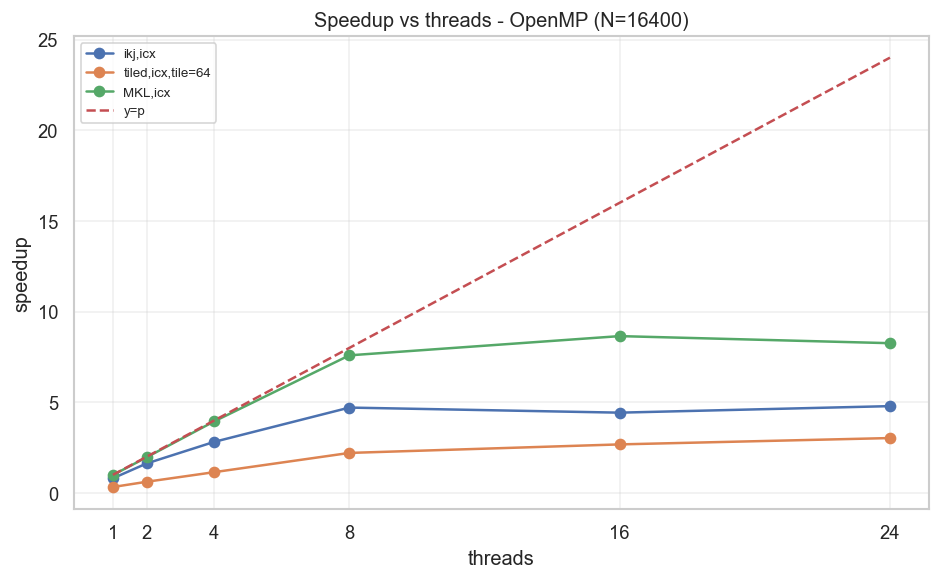

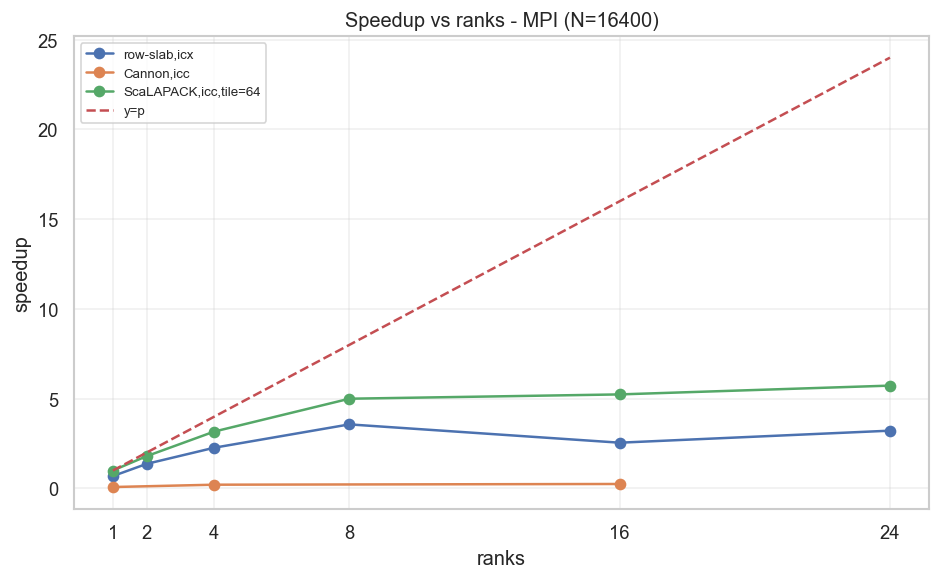

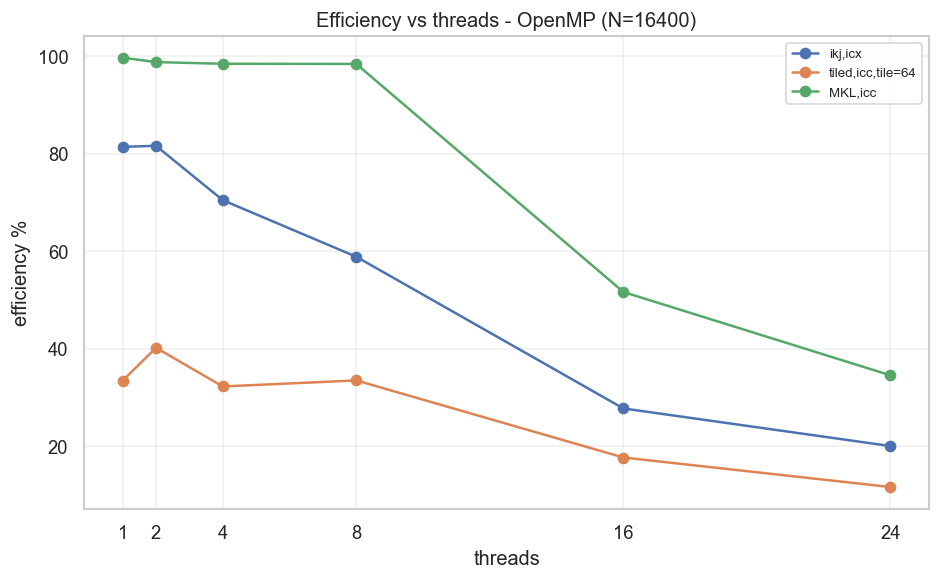

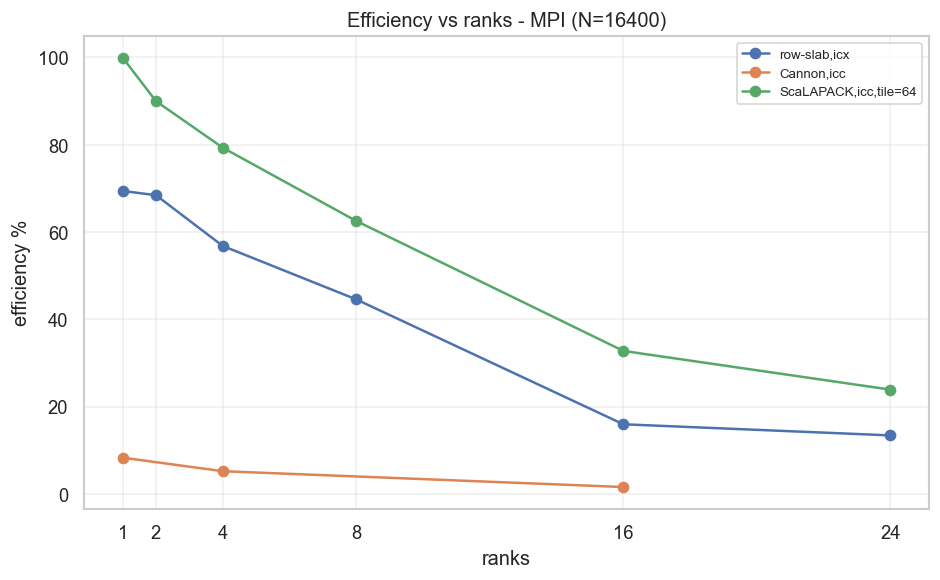

N usato: 16400

Configurazioni migliori per SPEEDUP - OpenMP:
 - ikj,icx
   speedup max = 4.790 @ p=24
 - tiled,icx,tile=64
   speedup max = 3.030 @ p=24
 - MKL,icx
   speedup max = 8.650 @ p=16

Configurazioni migliori per SPEEDUP - MPI:
 - row-slab,icx
   speedup max = 3.570 @ p=8
 - Cannon,icc
   speedup max = 0.250 @ p=16
 - ScaLAPACK,icc,tile=64
   speedup max = 5.730 @ p=24

Configurazioni migliori per EFFICIENCY - OpenMP:
 - ikj,icx
   efficiency max = 81.600% @ p=2
 - tiled,icc,tile=64
   efficiency max = 40.150% @ p=2
 - MKL,icc
   efficiency max = 98.780% @ p=2

Configurazioni migliori per EFFICIENCY - MPI:
 - row-slab,icx
   efficiency max = 68.440% @ p=2
 - Cannon,icc
   efficiency max = 5.200% @ p=4
 - ScaLAPACK,icc,tile=64
   efficiency max = 89.990% @ p=2


In [98]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Parametro principale
# =========================
N_SCALE = 16400

# =========================
# Lettura CSV
# =========================
def load_csv(filename):
    candidates = [
        Path(filename),
        Path("metrics_tables") / filename,
        Path("plot_scripts") / "metrics_tables" / filename,
        Path.cwd() / "plot_scripts" / "metrics_tables" / filename,
        Path.cwd() / "metrics_tables" / filename,
        Path("/Users/irynasavchuk/Desktop/cartella senza nome/HPC-MATMUL/plot_scripts/metrics_tables") / filename,
    ]
    for p in candidates:
        if p.exists():
            return pd.read_csv(p)

    matches = list(Path(".").rglob(filename))
    if matches:
        return pd.read_csv(matches[0])

    raise FileNotFoundError(f"File non trovato: {filename}")

omp = load_csv("omp_all_metrics.csv")
mpi = load_csv("mpi_all_metrics.csv")

# =========================
# Pulizia colonne
# =========================
for df in (omp, mpi):
    if "TileSize" in df.columns:
        df["TileSize"] = df["TileSize"].fillna("-").astype(str)
    if "Threads/Ranks" in df.columns:
        df["Threads/Ranks"] = pd.to_numeric(df["Threads/Ranks"], errors="coerce")
    if "GFLOPS" in df.columns:
        df["GFLOPS"] = pd.to_numeric(df["GFLOPS"], errors="coerce")
    if "Speedup" in df.columns:
        df["Speedup"] = pd.to_numeric(df["Speedup"], errors="coerce")
    if "Efficiency_%" in df.columns:
        df["Efficiency_%"] = pd.to_numeric(df["Efficiency_%"], errors="coerce")
    if "Time_s" in df.columns:
        df["Time_s"] = pd.to_numeric(df["Time_s"], errors="coerce")

# =========================
# Etichette leggibili
# =========================
nice = {
    "omp-ikj": "ikj",
    "omp-tile": "tiled",
    "mkl-omp": "MKL",
    "mpi-ikj": "row-slab",
    "mpi-cannon": "Cannon",
    "scalapack": "ScaLAPACK",
}

# =========================
# Label configurazione
# =========================
def config_to_label(config):
    label = nice.get(config["Test"], config["Test"])
    extras = []

    if "Compiler" in config and pd.notna(config["Compiler"]):
        extras.append(f"{config['Compiler']}")
    if "TileSize" in config and str(config["TileSize"]) not in ["-", "nan"]:
        extras.append(f"tile={config['TileSize']}")

    return f"{label}," + ",".join(extras) if extras else label

# =========================
# Scelta migliore configurazione
# =========================
def choose_best_config_precomputed(df, test_name, n_value, metric_col, exclude_p1=False, fixed_tile=None):
    """
    Sceglie UNA configurazione fissa senza ricalcolare niente.
    Usa direttamente il valore già presente nel CSV.

    fixed_tile:
        se non è None, filtra la configurazione su quel TileSize
        (utile per omp-tile, ad esempio fixed_tile='64')
    """
    d = df[(df["Test"] == test_name) & (df["N"] == n_value)].copy()

    if d.empty:
        return None, None

    # fissa tile solo se richiesto e se la colonna esiste
    if fixed_tile is not None and "TileSize" in d.columns:
        d = d[d["TileSize"].astype(str) == str(fixed_tile)].copy()

    if d.empty:
        return None, None

    metric_cols = {"N", "Threads/Ranks", "Time_s", "GFLOPS", "Speedup", "Efficiency_%"}
    config_cols = [c for c in d.columns if c not in metric_cols | {"Test"}]

    candidates = []

    for key, g in d.groupby(config_cols, dropna=False):
        g = g.copy()
        g = g.dropna(subset=["Threads/Ranks", metric_col])

        if g.empty or g["Threads/Ranks"].nunique() < 2:
            continue

        score_df = g.copy()
        if exclude_p1:
            score_df = score_df[score_df["Threads/Ranks"] > 1]

        if score_df.empty:
            continue

        score = score_df[metric_col].max()

        reduced = (
            g.sort_values([metric_col, "GFLOPS", "Time_s"], ascending=[False, False, True])
             .groupby("Threads/Ranks", as_index=False)
             .first()
             .sort_values("Threads/Ranks")
        )

        if not isinstance(key, tuple):
            key = (key,)

        cfg = dict(zip(config_cols, key))
        cfg["Test"] = test_name

        candidates.append((score, cfg, reduced))

    if not candidates:
        return None, None

    candidates.sort(key=lambda x: x[0], reverse=True)
    return candidates[0][1], candidates[0][2]
# =========================
# Test da considerare
# =========================
omp_tests = ["omp-ikj", "omp-tile", "mkl-omp"]
mpi_tests = ["mpi-ikj", "mpi-cannon", "scalapack"]

# =========================
# Curve migliori per SPEEDUP
# =========================
omp_speedup_curves = []
for t in omp_tests:
    fixed_tile = "64" if t == "omp-tile" else None
    cfg, curve = choose_best_config_precomputed(
        omp, t, N_SCALE,
        metric_col="Speedup",
        exclude_p1=False,
        fixed_tile=fixed_tile
    )
    if curve is not None:
        omp_speedup_curves.append((cfg, curve))

mpi_speedup_curves = []
for t in mpi_tests:
    cfg, curve = choose_best_config_precomputed(
        mpi, t, N_SCALE,
        metric_col="Speedup",
        exclude_p1=False
    )
    if curve is not None:
        mpi_speedup_curves.append((cfg, curve))

# =========================
# Curve migliori per EFFICIENCY
# =========================
omp_eff_curves = []
for t in omp_tests:
    fixed_tile = "64" if t == "omp-tile" else None
    cfg, curve = choose_best_config_precomputed(
        omp, t, N_SCALE,
        metric_col="Efficiency_%",
        exclude_p1=True,
        fixed_tile=fixed_tile
    )
    if curve is not None:
        omp_eff_curves.append((cfg, curve))

mpi_eff_curves = []
for t in mpi_tests:
    cfg, curve = choose_best_config_precomputed(
        mpi, t, N_SCALE,
        metric_col="Efficiency_%",
        exclude_p1=True   # evita che vinca sempre p=1
    )
    if curve is not None:
        mpi_eff_curves.append((cfg, curve))

# =========================
# Plot 1: Speedup OpenMP
# =========================
plt.figure(figsize=(8, 5))

for cfg, curve in omp_speedup_curves:
    plt.plot(
        curve["Threads/Ranks"],
        curve["Speedup"],
        marker="o",
        label=config_to_label(cfg)
    )

if omp_speedup_curves:
    x_omp = sorted(set(np.concatenate([c["Threads/Ranks"].values for _, c in omp_speedup_curves])))
    plt.plot(x_omp, x_omp, linestyle="--", label="y=p")

plt.title(f"Speedup vs threads - OpenMP (N={N_SCALE})")
plt.xlabel("threads")
plt.ylabel("speedup")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.xticks([1, 2, 4, 8, 16, 24])
plt.tight_layout()
plt.show()

# =========================
# Plot 2: Speedup MPI
# =========================
plt.figure(figsize=(8, 5))

for cfg, curve in mpi_speedup_curves:
    plt.plot(
        curve["Threads/Ranks"],
        curve["Speedup"],
        marker="o",
        label=config_to_label(cfg)
    )

if mpi_speedup_curves:
    x_mpi = sorted(set(np.concatenate([c["Threads/Ranks"].values for _, c in mpi_speedup_curves])))
    plt.plot(x_mpi, x_mpi, linestyle="--", label="y=p")

plt.title(f"Speedup vs ranks - MPI (N={N_SCALE})")
plt.xlabel("ranks")
plt.ylabel("speedup")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.xticks([1, 2, 4, 8, 16, 24])
plt.tight_layout()
plt.show()

# =========================
# Plot 3: Efficiency OpenMP
# =========================
plt.figure(figsize=(8, 5))

for cfg, curve in omp_eff_curves:
    plt.plot(
        curve["Threads/Ranks"],
        curve["Efficiency_%"],
        marker="o",
        label=config_to_label(cfg)
    )

plt.title(f"Efficiency vs threads - OpenMP (N={N_SCALE})")
plt.xlabel("threads")
plt.ylabel("efficiency %")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.xticks([1, 2, 4, 8, 16, 24])
plt.tight_layout()
plt.show()

# =========================
# Plot 4: Efficiency MPI
# =========================
plt.figure(figsize=(8, 5))

for cfg, curve in mpi_eff_curves:
    plt.plot(
        curve["Threads/Ranks"],
        curve["Efficiency_%"],
        marker="o",
        label=config_to_label(cfg)
    )

plt.title(f"Efficiency vs ranks - MPI (N={N_SCALE})")
plt.xlabel("ranks")
plt.ylabel("efficiency %")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.xticks([1, 2, 4, 8, 16, 24])
plt.tight_layout()
plt.show()

# =========================
# Stampa configurazioni scelte
# =========================
print(f"N usato: {N_SCALE}")

print("\nConfigurazioni migliori per SPEEDUP - OpenMP:")
for cfg, curve in omp_speedup_curves:
    best_row = curve.loc[curve["Speedup"].idxmax()]
    print(f" - {config_to_label(cfg)}")
    print(f"   speedup max = {best_row['Speedup']:.3f} @ p={int(best_row['Threads/Ranks'])}")

print("\nConfigurazioni migliori per SPEEDUP - MPI:")
for cfg, curve in mpi_speedup_curves:
    best_row = curve.loc[curve["Speedup"].idxmax()]
    print(f" - {config_to_label(cfg)}")
    print(f"   speedup max = {best_row['Speedup']:.3f} @ p={int(best_row['Threads/Ranks'])}")

print("\nConfigurazioni migliori per EFFICIENCY - OpenMP:")
for cfg, curve in omp_eff_curves:
    tmp = curve[curve["Threads/Ranks"] > 1].copy()
    best_row = tmp.loc[tmp["Efficiency_%"].idxmax()]
    print(f" - {config_to_label(cfg)}")
    print(f"   efficiency max = {best_row['Efficiency_%']:.3f}% @ p={int(best_row['Threads/Ranks'])}")

print("\nConfigurazioni migliori per EFFICIENCY - MPI:")
for cfg, curve in mpi_eff_curves:
    tmp = curve[curve["Threads/Ranks"] > 1].copy()
    best_row = tmp.loc[tmp["Efficiency_%"].idxmax()]
    print(f" - {config_to_label(cfg)}")
    print(f"   efficiency max = {best_row['Efficiency_%']:.3f}% @ p={int(best_row['Threads/Ranks'])}")

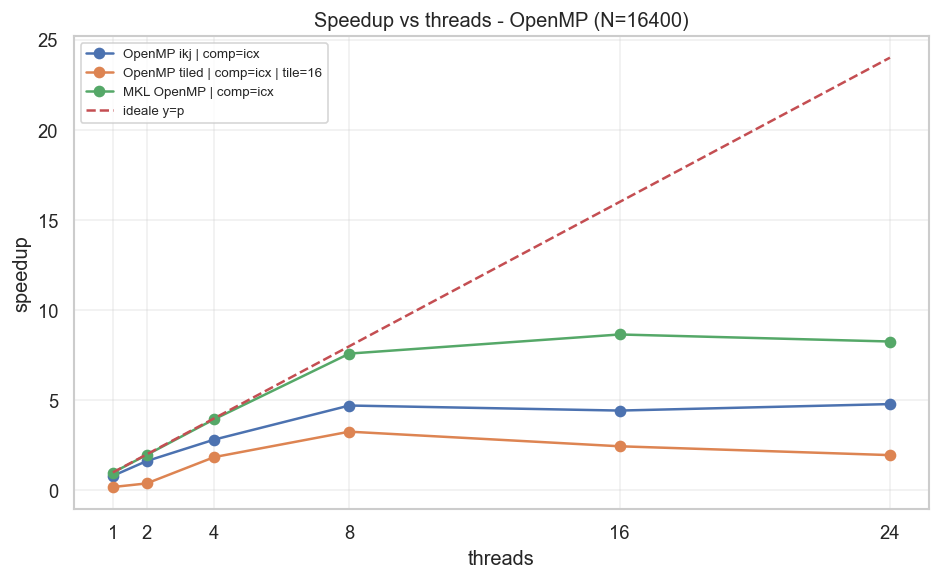

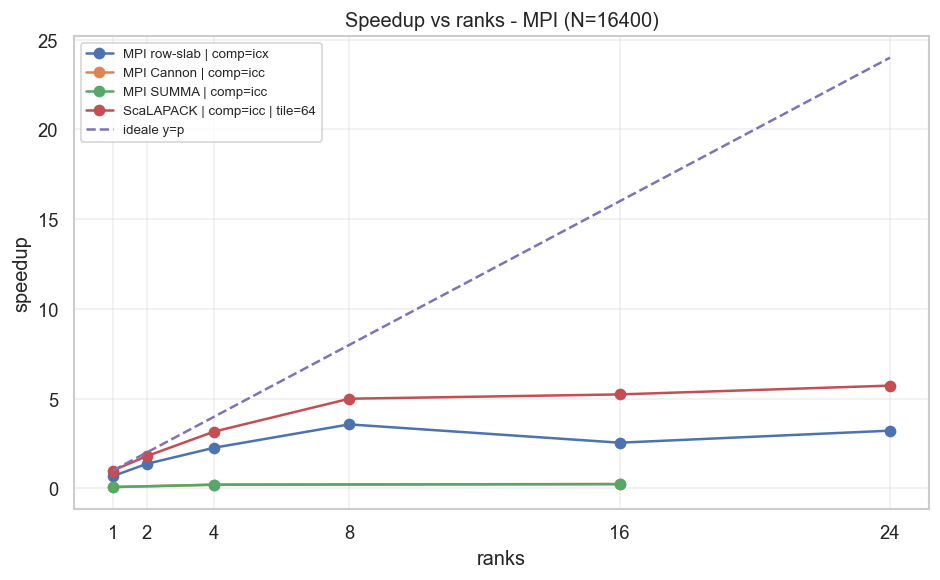

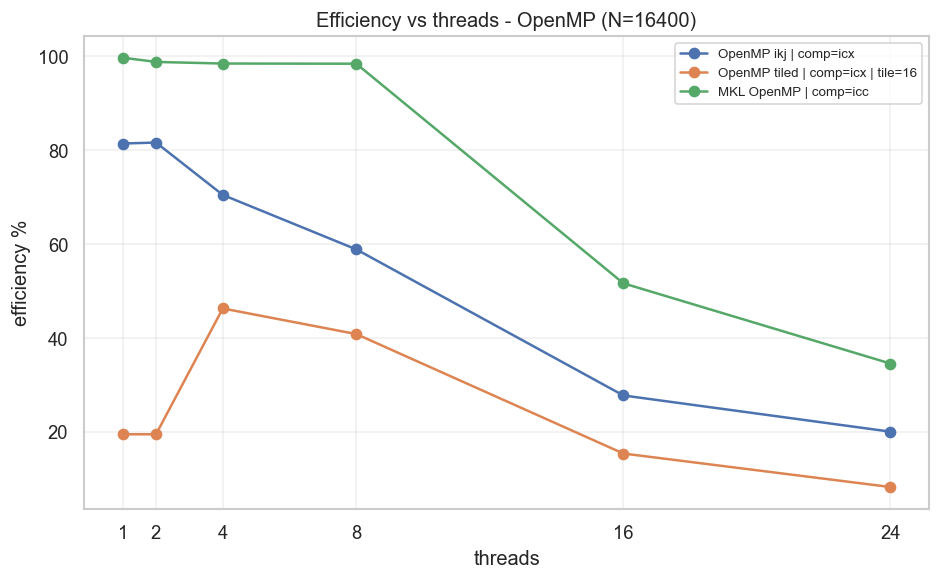

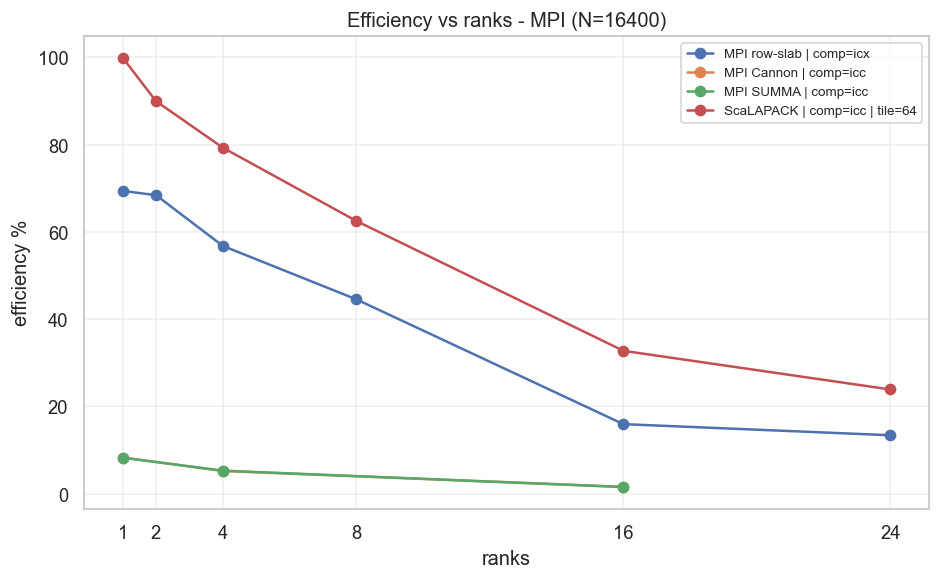

N usato: 16400

Configurazioni migliori per SPEEDUP - OpenMP:
 - OpenMP ikj | comp=icx
   speedup max = 4.790 @ p=24
 - OpenMP tiled | comp=icx | tile=16
   speedup max = 3.260 @ p=8
 - MKL OpenMP | comp=icx
   speedup max = 8.650 @ p=16

Configurazioni migliori per SPEEDUP - MPI:
 - MPI row-slab | comp=icx
   speedup max = 3.570 @ p=8
 - MPI Cannon | comp=icc
   speedup max = 0.250 @ p=16
 - MPI SUMMA | comp=icc
   speedup max = 0.240 @ p=16
 - ScaLAPACK | comp=icc | tile=64
   speedup max = 5.730 @ p=24

Configurazioni migliori per EFFICIENCY - OpenMP:
 - OpenMP ikj | comp=icx
   efficiency max = 81.600% @ p=2
 - OpenMP tiled | comp=icx | tile=16
   efficiency max = 46.240% @ p=4
 - MKL OpenMP | comp=icc
   efficiency max = 98.780% @ p=2

Configurazioni migliori per EFFICIENCY - MPI:
 - MPI row-slab | comp=icx
   efficiency max = 68.440% @ p=2
 - MPI Cannon | comp=icc
   efficiency max = 5.200% @ p=4
 - MPI SUMMA | comp=icc
   efficiency max = 5.290% @ p=4
 - ScaLAPACK | comp=icc | t

In [95]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Parametro principale
# =========================
N_SCALE = 16400

# =========================
# Lettura CSV
# =========================
def load_csv(filename):
    candidates = [
        Path(filename),
        Path("metrics_tables") / filename,
        Path("plot_scripts") / "metrics_tables" / filename,
        Path.cwd() / "plot_scripts" / "metrics_tables" / filename,
        Path.cwd() / "metrics_tables" / filename,
        Path("/Users/irynasavchuk/Desktop/cartella senza nome/HPC-MATMUL/plot_scripts/metrics_tables") / filename,
    ]
    for p in candidates:
        if p.exists():
            return pd.read_csv(p)

    matches = list(Path(".").rglob(filename))
    if matches:
        return pd.read_csv(matches[0])

    raise FileNotFoundError(f"File non trovato: {filename}")

omp = load_csv("omp_all_metrics.csv")
mpi = load_csv("mpi_all_metrics.csv")

# =========================
# Pulizia colonne
# =========================
for df in (omp, mpi):
    if "TileSize" in df.columns:
        df["TileSize"] = df["TileSize"].fillna("-").astype(str)
    if "Threads/Ranks" in df.columns:
        df["Threads/Ranks"] = pd.to_numeric(df["Threads/Ranks"], errors="coerce")
    if "GFLOPS" in df.columns:
        df["GFLOPS"] = pd.to_numeric(df["GFLOPS"], errors="coerce")
    if "Speedup" in df.columns:
        df["Speedup"] = pd.to_numeric(df["Speedup"], errors="coerce")
    if "Efficiency_%" in df.columns:
        df["Efficiency_%"] = pd.to_numeric(df["Efficiency_%"], errors="coerce")
    if "Time_s" in df.columns:
        df["Time_s"] = pd.to_numeric(df["Time_s"], errors="coerce")

# =========================
# Etichette leggibili
# =========================
nice = {
    "omp-ikj": "OpenMP ikj",
    "omp-tile": "OpenMP tiled",
    "mkl-omp": "MKL OpenMP",
    "mpi-ikj": "MPI row-slab",
    "mpi-cannon": "MPI Cannon",
    "mpi-summa": "MPI SUMMA",
    "scalapack": "ScaLAPACK",
}

# =========================
# Label configurazione
# =========================
def config_to_label(config):
    label = nice.get(config["Test"], config["Test"])
    extras = []

    if "Compiler" in config and pd.notna(config["Compiler"]):
        extras.append(f"comp={config['Compiler']}")

    if "TileSize" in config and str(config["TileSize"]) not in ["-", "nan"]:
        extras.append(f"tile={config['TileSize']}")

    return f"{label} | " + " | ".join(extras) if extras else label

# =========================
# Scelta migliore configurazione
# =========================
def choose_best_config_precomputed(df, test_name, n_value, metric_col, exclude_p1=False):
    """
    Sceglie UNA configurazione fissa senza ricalcolare niente.
    Usa direttamente il valore già presente nel CSV:
    - metric_col = 'Speedup'
    - metric_col = 'Efficiency_%'

    exclude_p1=True serve solo per efficiency, per non far vincere sempre p=1.
    """
    d = df[(df["Test"] == test_name) & (df["N"] == n_value)].copy()

    if d.empty:
        return None, None

    metric_cols = {"N", "Threads/Ranks", "Time_s", "GFLOPS", "Speedup", "Efficiency_%"}
    config_cols = [c for c in d.columns if c not in metric_cols | {"Test"}]

    candidates = []

    for key, g in d.groupby(config_cols, dropna=False):
        g = g.copy()
        g = g.dropna(subset=["Threads/Ranks", metric_col])

        if g.empty or g["Threads/Ranks"].nunique() < 2:
            continue

        # score usato per decidere la configurazione migliore
        score_df = g.copy()
        if exclude_p1:
            score_df = score_df[score_df["Threads/Ranks"] > 1]

        if score_df.empty:
            continue

        score = score_df[metric_col].max()

        # riduce eventuali duplicati sullo stesso numero di thread/rank
        # tenendo il record con metrica migliore
        reduced = (
            g.sort_values([metric_col, "GFLOPS", "Time_s"], ascending=[False, False, True])
             .groupby("Threads/Ranks", as_index=False)
             .first()
             .sort_values("Threads/Ranks")
        )

        if not isinstance(key, tuple):
            key = (key,)

        cfg = dict(zip(config_cols, key))
        cfg["Test"] = test_name

        candidates.append((score, cfg, reduced))

    if not candidates:
        return None, None

    candidates.sort(key=lambda x: x[0], reverse=True)
    return candidates[0][1], candidates[0][2]

# =========================
# Test da considerare
# =========================
omp_tests = ["omp-ikj", "omp-tile", "mkl-omp"]
mpi_tests = ["mpi-ikj", "mpi-cannon", "mpi-summa", "scalapack"]

# =========================
# Curve migliori per SPEEDUP
# =========================
omp_speedup_curves = []
for t in omp_tests:
    cfg, curve = choose_best_config_precomputed(
        omp, t, N_SCALE,
        metric_col="Speedup",
        exclude_p1=False
    )
    if curve is not None:
        omp_speedup_curves.append((cfg, curve))

mpi_speedup_curves = []
for t in mpi_tests:
    cfg, curve = choose_best_config_precomputed(
        mpi, t, N_SCALE,
        metric_col="Speedup",
        exclude_p1=False
    )
    if curve is not None:
        mpi_speedup_curves.append((cfg, curve))

# =========================
# Curve migliori per EFFICIENCY
# =========================
omp_eff_curves = []
for t in omp_tests:
    cfg, curve = choose_best_config_precomputed(
        omp, t, N_SCALE,
        metric_col="Efficiency_%",
        exclude_p1=True   # evita che vinca sempre p=1
    )
    if curve is not None:
        omp_eff_curves.append((cfg, curve))

mpi_eff_curves = []
for t in mpi_tests:
    cfg, curve = choose_best_config_precomputed(
        mpi, t, N_SCALE,
        metric_col="Efficiency_%",
        exclude_p1=True   # evita che vinca sempre p=1
    )
    if curve is not None:
        mpi_eff_curves.append((cfg, curve))

# =========================
# Plot 1: Speedup OpenMP
# =========================
plt.figure(figsize=(8, 5))

for cfg, curve in omp_speedup_curves:
    plt.plot(
        curve["Threads/Ranks"],
        curve["Speedup"],
        marker="o",
        label=config_to_label(cfg)
    )

if omp_speedup_curves:
    x_omp = sorted(set(np.concatenate([c["Threads/Ranks"].values for _, c in omp_speedup_curves])))
    plt.plot(x_omp, x_omp, linestyle="--", label="ideale y=p")

plt.title(f"Speedup vs threads - OpenMP (N={N_SCALE})")
plt.xlabel("threads")
plt.ylabel("speedup")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.xticks([1, 2, 4, 8, 16, 24])
plt.tight_layout()
plt.show()

# =========================
# Plot 2: Speedup MPI
# =========================
plt.figure(figsize=(8, 5))

for cfg, curve in mpi_speedup_curves:
    plt.plot(
        curve["Threads/Ranks"],
        curve["Speedup"],
        marker="o",
        label=config_to_label(cfg)
    )

if mpi_speedup_curves:
    x_mpi = sorted(set(np.concatenate([c["Threads/Ranks"].values for _, c in mpi_speedup_curves])))
    plt.plot(x_mpi, x_mpi, linestyle="--", label="ideale y=p")

plt.title(f"Speedup vs ranks - MPI (N={N_SCALE})")
plt.xlabel("ranks")
plt.ylabel("speedup")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.xticks([1, 2, 4, 8, 16, 24])
plt.tight_layout()
plt.show()

# =========================
# Plot 3: Efficiency OpenMP
# =========================
plt.figure(figsize=(8, 5))

for cfg, curve in omp_eff_curves:
    plt.plot(
        curve["Threads/Ranks"],
        curve["Efficiency_%"],
        marker="o",
        label=config_to_label(cfg)
    )

plt.title(f"Efficiency vs threads - OpenMP (N={N_SCALE})")
plt.xlabel("threads")
plt.ylabel("efficiency %")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.xticks([1, 2, 4, 8, 16, 24])
plt.tight_layout()
plt.show()

# =========================
# Plot 4: Efficiency MPI
# =========================
plt.figure(figsize=(8, 5))

for cfg, curve in mpi_eff_curves:
    plt.plot(
        curve["Threads/Ranks"],
        curve["Efficiency_%"],
        marker="o",
        label=config_to_label(cfg)
    )

plt.title(f"Efficiency vs ranks - MPI (N={N_SCALE})")
plt.xlabel("ranks")
plt.ylabel("efficiency %")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.xticks([1, 2, 4, 8, 16, 24])
plt.tight_layout()
plt.show()

# =========================
# Stampa configurazioni scelte
# =========================
print(f"N usato: {N_SCALE}")

print("\nConfigurazioni migliori per SPEEDUP - OpenMP:")
for cfg, curve in omp_speedup_curves:
    best_row = curve.loc[curve["Speedup"].idxmax()]
    print(f" - {config_to_label(cfg)}")
    print(f"   speedup max = {best_row['Speedup']:.3f} @ p={int(best_row['Threads/Ranks'])}")

print("\nConfigurazioni migliori per SPEEDUP - MPI:")
for cfg, curve in mpi_speedup_curves:
    best_row = curve.loc[curve["Speedup"].idxmax()]
    print(f" - {config_to_label(cfg)}")
    print(f"   speedup max = {best_row['Speedup']:.3f} @ p={int(best_row['Threads/Ranks'])}")

print("\nConfigurazioni migliori per EFFICIENCY - OpenMP:")
for cfg, curve in omp_eff_curves:
    tmp = curve[curve["Threads/Ranks"] > 1].copy()
    best_row = tmp.loc[tmp["Efficiency_%"].idxmax()]
    print(f" - {config_to_label(cfg)}")
    print(f"   efficiency max = {best_row['Efficiency_%']:.3f}% @ p={int(best_row['Threads/Ranks'])}")

print("\nConfigurazioni migliori per EFFICIENCY - MPI:")
for cfg, curve in mpi_eff_curves:
    tmp = curve[curve["Threads/Ranks"] > 1].copy()
    best_row = tmp.loc[tmp["Efficiency_%"].idxmax()]
    print(f" - {config_to_label(cfg)}")
    print(f"   efficiency max = {best_row['Efficiency_%']:.3f}% @ p={int(best_row['Threads/Ranks'])}")